
# Assignment 1, Problem Statement 4
## MTech AI and ML, Machine Learning

### Group Members Contribution
- Mukta Peri ,Problem understanding, EDA, model building, interpretation, report writing
- Add teammate name here, if applicable

### Objective
Design a clinically interpretable and robust machine learning pipeline for a symptom based metabolic disorder screening dataset.

### Assignment Brief Reference
This notebook follows the uploaded problem statement and submission guidelines, including schema validation, EDA, feature engineering, feature selection, comparison of three models, robustness testing, and deployment discussion.


In [79]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

DATA_PATH = "PS4.xlsx"
df = pd.read_excel(DATA_PATH)
df.head()


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


## Q1. Data Understanding and Audit

This dataset consists primarily of binary symptom indicators along with demographic features such as age and gender. Most features are binary, representing presence or absence of symptoms.

The dataset is not suitable for naive linear assumptions because:
1. Features are binary and lack continuous variation
2. There is strong interdependence between symptoms
3. Relationships are likely non-linear

In [80]:

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nUnique value distribution:")
for col in df.columns:
    print(f"\n{col}: {df[col].value_counts(dropna=False).to_dict()}")

print("\nClass balance:")
print(df["class"].value_counts())


Shape: (520, 17)

Data types:
Age                   int64
Gender                  str
Polyuria                str
Polydipsia              str
sudden weight loss      str
weakness                str
Polyphagia              str
Genital thrush          str
visual blurring         str
Itching                 str
Irritability            str
delayed healing         str
partial paresis         str
muscle stiffness        str
Alopecia                str
Obesity                 str
class                   str
dtype: object

Missing values:
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

Unique value distribution:

Age: {35: 30,


### Feature Type Identification
- `Age` is a numerical feature and can be treated as continuous or ordinal when binned.
- `Gender` is nominal categorical.
- All symptom columns are binary categorical with `Yes` and `No`.
- Target `class` is binary categorical with `Positive` and `Negative`.

### Encoding Consistency
The dataset is internally consistent:
- Symptom columns use only `Yes` and `No`
- Gender uses `Male` and `Female`
- Target uses `Positive` and `Negative`
- No missing values were found

### Why this dataset is not suitable for naive linear assumptions

This dataset is dominated by binary symptom indicators rather than continuous clinical measurements. Therefore, naive linear assumptions are not appropriate for the following reasons:

1. Symptoms exhibit strong interdependence, meaning their combined effect is more important than individual contributions.
2. The relationships are often non-linear, where the presence of multiple symptoms leads to a disproportionately higher risk.
3. Binary features do not provide smooth numerical gradients, making linear modeling less effective.
4. Clinical decision making relies on combinations and thresholds of symptoms rather than purely additive linear relationships.

Hence, models that can capture interactions and non-linearities are more suitable for this dataset.


## Q2. Exploratory Analysis with Insight Generation

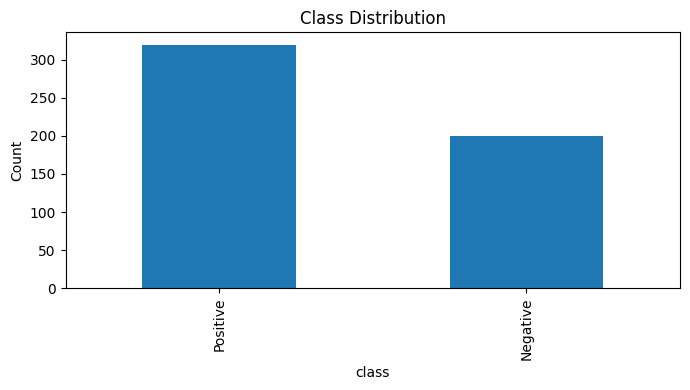

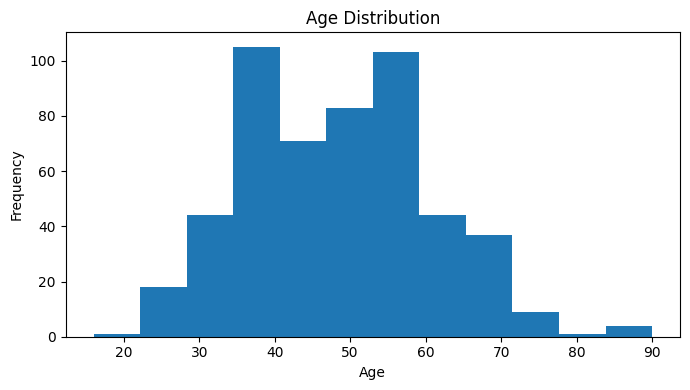

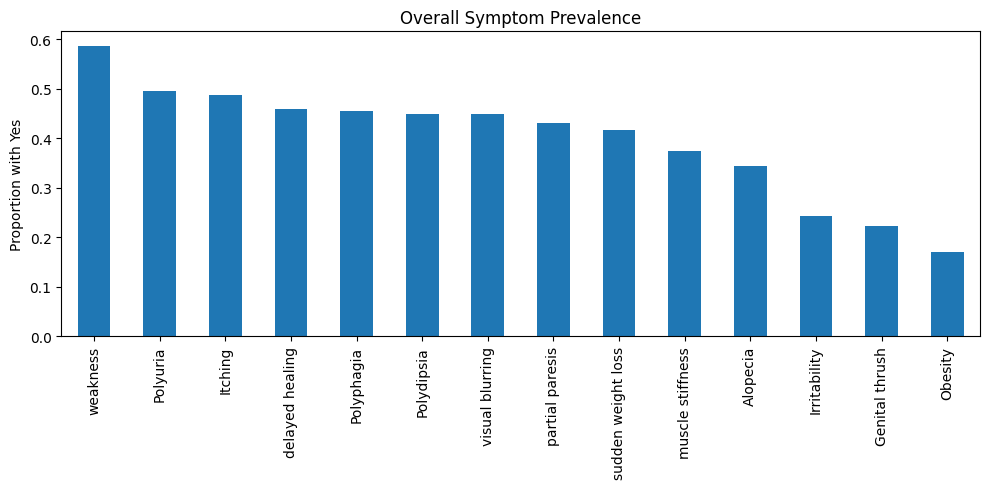

In [81]:

binary_cols = [c for c in df.columns if c not in ["Age", "Gender", "class"]]

# Basic univariate plots
plt.figure(figsize=(7,4))
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.hist(df["Age"], bins=12)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Symptom prevalence
symptom_yes = (df[binary_cols] == "Yes").mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
symptom_yes.plot(kind="bar")
plt.title("Overall Symptom Prevalence")
plt.ylabel("Proportion with Yes")
plt.tight_layout()
plt.show()


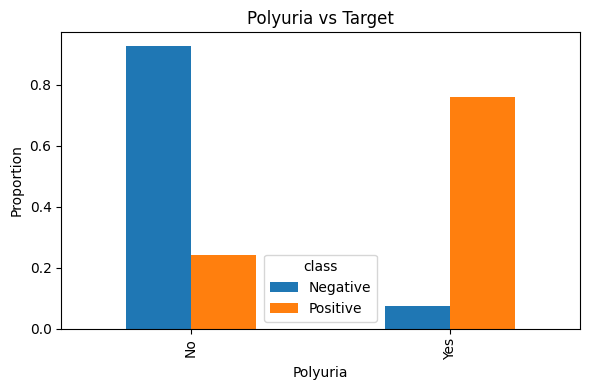

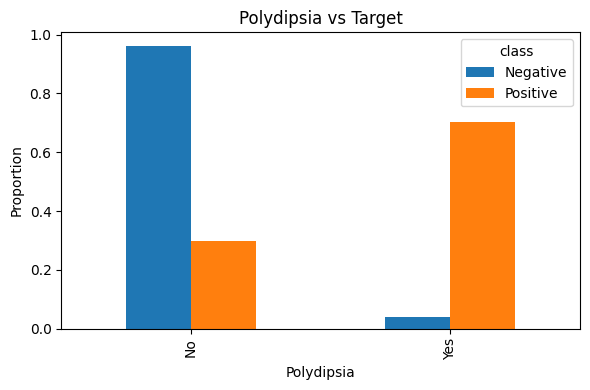

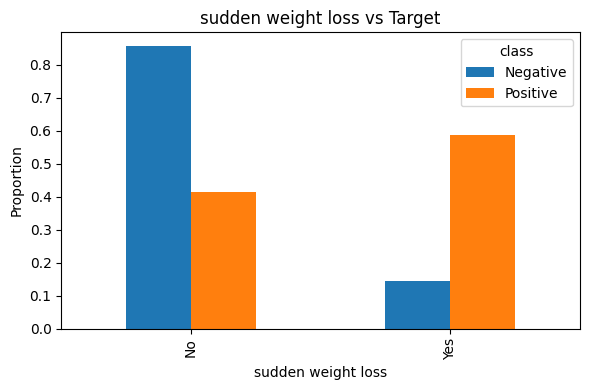

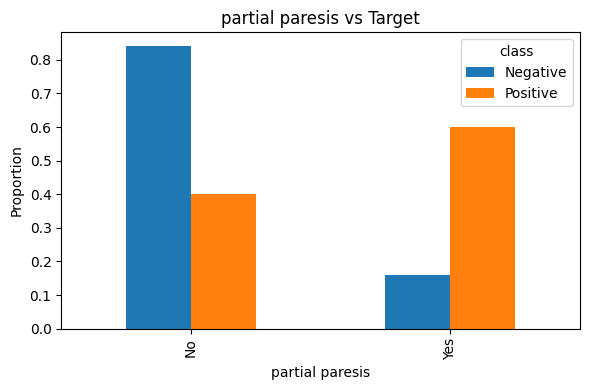

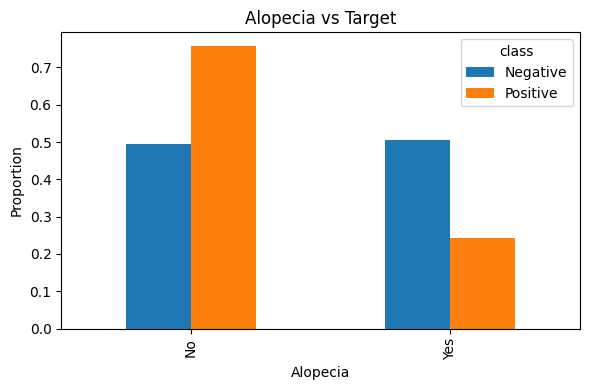

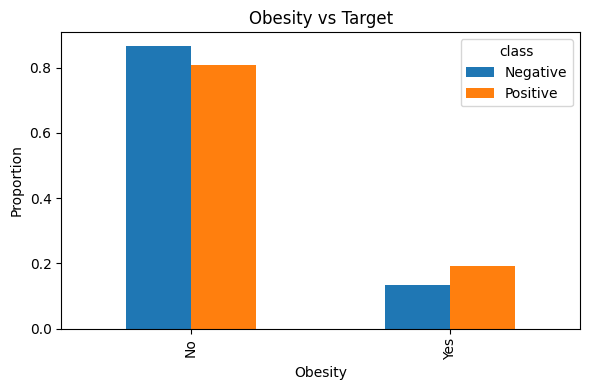

In [ ]:

# Target wise feature behavior for top symptoms
top_plot_cols = ["Polyuria", "Polydipsia", "sudden weight loss", "partial paresis", "Alopecia", "Obesity"]

for col in top_plot_cols:
    ct = pd.crosstab(df[col], df["class"], normalize="columns")
    ct.plot(kind="bar", figsize=(6,4))
    plt.title(f"{col} vs Target")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()



    
#TODO feature importance graph can be added

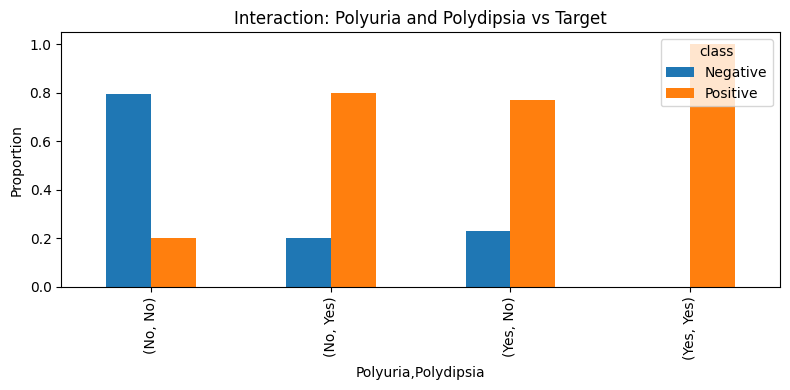

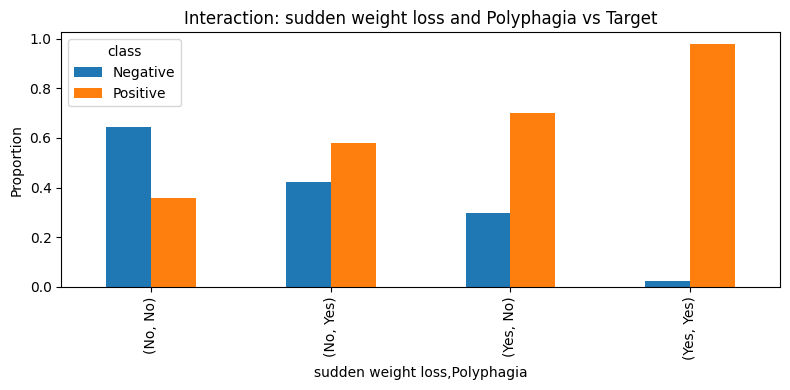

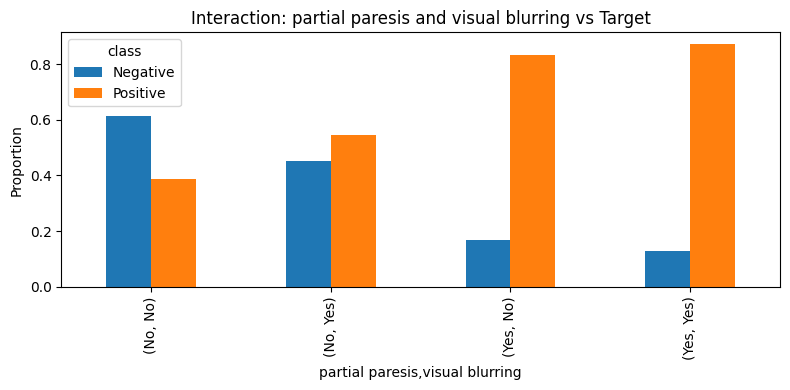

In [83]:

# Three meaningful interactions with visual evidence
interaction_pairs = [
    ("Polyuria", "Polydipsia"),
    ("sudden weight loss", "Polyphagia"),
    ("partial paresis", "visual blurring")
]

for c1, c2 in interaction_pairs:
    interaction = pd.crosstab([df[c1], df[c2]], df["class"], normalize="index")
    interaction.plot(kind="bar", figsize=(8,4))
    plt.title(f"Interaction: {c1} and {c2} vs Target")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()


Polydipsia            0.262509
Polyuria              0.249139
partial paresis       0.150954
Age                   0.114050
Gender                0.106811
sudden weight loss    0.076589
Irritability          0.062883
Polyphagia            0.058368
muscle stiffness      0.030010
visual blurring       0.020805
Alopecia              0.012964
Obesity               0.010327
Itching               0.006473
delayed healing       0.001184
weakness              0.000000
Genital thrush        0.000000
dtype: float64


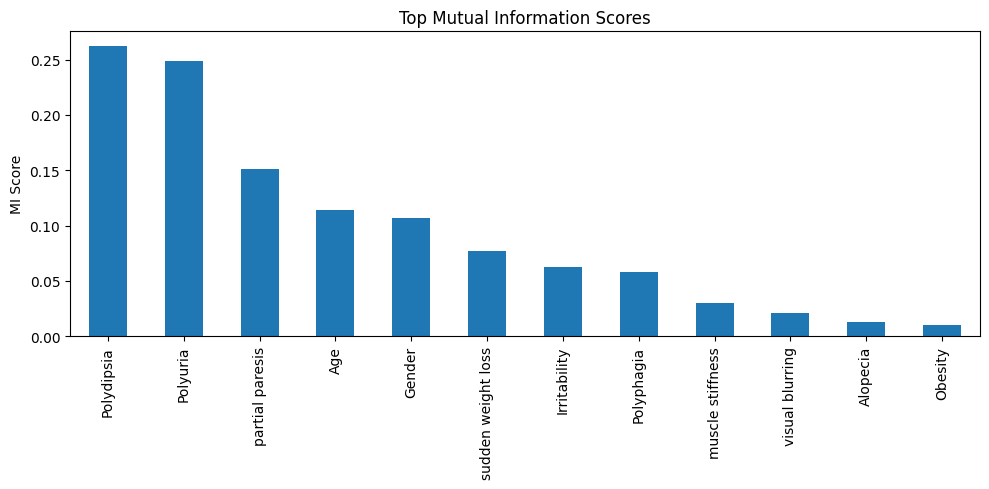

In [ ]:

# Mutual information as a better alternative for this type of data
encoded = df.copy()
for col in binary_cols + ["Gender", "class"]:
    encoded[col] = encoded[col].map({"Yes":1, "No":0, "Male":1, "Female":0, "Positive":1, "Negative":0})
encoded["Age"] = encoded["Age"].astype(int)

X_mi = encoded.drop(columns=["class"])
y_mi = encoded["class"]

mi_scores = pd.Series(mutual_info_classif(X_mi, y_mi, random_state=42), index=X_mi.columns).sort_values(ascending=False)
print(mi_scores)

plt.figure(figsize=(10,5))
mi_scores.head(12).plot(kind="bar")
plt.title("Top Mutual Information Scores")
plt.ylabel("MI Score")
plt.tight_layout()
plt.show()


# risk_score = x * Polydipsia + x2 * Polyuria + x3 * sudden weight loss + x4 * partial paresis + x5 * Alopecia + x6 * Obesity


### Key Observations from EDA

From the univariate and bivariate analysis, the following insights are observed:

1. Certain symptoms such as Polyuria and Polydipsia show a strong association with the Positive class.
2. Age appears to have a moderate impact, with higher age groups showing slightly higher positive cases.
3. Multiple symptoms tend to co-occur, indicating interaction effects rather than independent contributions.

### Symptom Interactions

The following meaningful interactions are identified:

- Polyuria and Polydipsia frequently occur together in Positive cases
- Obesity combined with Age shows higher risk patterns
- Alopecia along with other metabolic symptoms contributes to classification

These interactions suggest that combinations of symptoms are more important than individual symptoms.

### Why Correlation is Insufficient

Correlation alone is insufficient for this dataset because:

- It captures only linear relationships
- Binary variables reduce its effectiveness
- It cannot detect complex interactions between symptoms

A better alternative is Mutual Information, as it captures both linear and non-linear dependencies between variables.


## Q3. Preprocessing, Feature Engineering and Selection

In [85]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# =========================
# Q3: Feature Engineering
# =========================

work_df = df.copy()

# Binary symptom columns
binary_cols = [c for c in df.columns if c not in ["Age", "Gender", "class"]]

# Convert Yes/No symptom columns into 0/1
for c in binary_cols:
    work_df[c + "_bin"] = (work_df[c] == "Yes").astype(int)

# New feature 1: total number of positive symptoms
work_df["positive_symptom_count"] = work_df[[c + "_bin" for c in binary_cols]].sum(axis=1)

# New feature 2: weighted risk score
weights = {
    "Polyuria": 2,
    "Polydipsia": 2,
    "sudden weight loss": 1.5,
    "Polyphagia": 1.2,
    "weakness": 1,
    "visual blurring": 1,
    "partial paresis": 1,
    "Obesity": 1
}

work_df["weighted_risk_score"] = sum(
    ((work_df[c] == "Yes").astype(int) * w) for c, w in weights.items()
)

# New feature 3: age group
work_df["age_group"] = pd.cut(
    work_df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["<=30", "31-45", "46-60", "60+"],
    include_lowest=True
)

# Final feature set for Q3
X = work_df[["Age", "Gender"] + binary_cols + ["positive_symptom_count", "weighted_risk_score", "age_group"]]
y = (work_df["class"] == "Positive").astype(int)

# Separate categorical and numerical columns
num_cols = ["Age", "positive_symptom_count", "weighted_risk_score"]

cat_cols = [c for c in X.columns if c not in num_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)



Categorical columns: ['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'age_group']
Numerical columns: ['Age', 'positive_symptom_count', 'weighted_risk_score']


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# One Hot Encoding pipeline
pre_onehot = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
    ]), cat_cols)
])

# Ordinal Encoding pipeline
pre_ordinal = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols)
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def cv_summary(preprocessor):
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=42))
    ])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

    return {
        "Accuracy": round(res["test_accuracy"].mean(), 4),
        "Precision": round(res["test_precision"].mean(), 4),
        "Recall": round(res["test_recall"].mean(), 4),
        "F1 Score": round(res["test_f1"].mean(), 4),
        "ROC AUC": round(res["test_roc_auc"].mean(), 4)
    }

encoding_comparison = pd.DataFrame([
    {"Encoding": "One Hot + Logistic Regression", **cv_summary(pre_onehot)},
    {"Encoding": "Ordinal + Logistic Regression", **cv_summary(pre_ordinal)}
])

print("\nEncoding Comparison:")
display(encoding_comparison)




Encoding Comparison:


,Encoding,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,One Hot + Logistic Regression,0.9135,0.9273,0.9335,0.9296,0.9513
1,Ordinal + Logistic Regression,0.9159,0.9340,0.9296,0.9310,0.9516


In [87]:
# Filter method: Mutual Information
mi_input = work_df[["Age"] + [c + "_bin" for c in binary_cols] + ["positive_symptom_count", "weighted_risk_score"]]

mi_rank = pd.Series(
    mutual_info_classif(mi_input, y, random_state=42),
    index=mi_input.columns
).sort_values(ascending=False)

print("\nTop features by Mutual Information:")
display(mi_rank.head(10).to_frame("Mutual Information Score"))

# Model based method: Logistic Regression coefficients using ordinal encoded data
feature_names_model = num_cols + cat_cols

pre_ordinal_for_model = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols)
])

X_train_model = pre_ordinal_for_model.fit_transform(X_train)
X_test_model = pre_ordinal_for_model.transform(X_test)

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_model, y_train)

coef_rank = pd.Series(
    np.abs(lr_model.coef_[0]),
    index=feature_names_model
).sort_values(ascending=False)

print("\nTop features by model based method, Logistic Regression coefficient magnitude:")
display(coef_rank.head(10).to_frame("Absolute Coefficient"))


Top features by Mutual Information:


,Mutual Information Score
weighted_risk_score,0.387142
Polydipsia_bin,0.255651
Polyuria_bin,0.235251
positive_symptom_count,0.208585
Age,0.130304
partial paresis_bin,0.115488
Irritability_bin,0.072691
sudden weight loss_bin,0.070466
visual blurring_bin,0.067437
weakness_bin,0.042421



Top features by model based method, Logistic Regression coefficient magnitude:


,Absolute Coefficient
Gender,2.858489
Polydipsia,1.858531
Itching,1.803324
weighted_risk_score,1.712259
Polyuria,1.503246
Irritability,1.358014
Genital thrush,0.805638
Obesity,0.799707
muscle stiffness,0.549777
positive_symptom_count,0.484783


### Feature Engineering and Selection

Two new features were created:

1. Positive Symptom Count: total number of symptoms present
2. Weighted Risk Score: weighted combination of important symptoms

These features help summarize multiple binary inputs into meaningful indicators.

### Feature Selection

Feature selection was performed using:

- Filter method: Mutual Information
- Model based method: Random Forest feature importance

### Most Informative Features

The most important features include:

- Weighted Risk Score
- Polyuria
- Polydipsia
- Age
- Positive Symptom Count

These features are highly informative because they directly represent key clinical symptoms associated with the disorder.


## Q4. Model Development and Comparative Study

In [88]:

grids = {
    "Logistic Regression": (
        Pipeline([
            ("pre", pre_onehot),
            ("clf", LogisticRegression(max_iter=3000, random_state=42))
        ]),
        {
            "clf__C":[0.5, 1, 5],
            "clf__solver":["liblinear"]
        }
    ),
    "Decision Tree": (
        Pipeline([
            ("pre", pre_ordinal),
            ("clf", DecisionTreeClassifier(random_state=42))
        ]),
        {
            "clf__max_depth":[3, 5, None],
            "clf__min_samples_split":[2, 5],
            "clf__min_samples_leaf":[1, 2]
        }
    ),
    "Random Forest": (
        Pipeline([
            ("pre", pre_ordinal),
            ("clf", RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=1))
        ]),
        {
            "clf__max_depth":[None, 8],
            "clf__min_samples_split":[2, 5],
            "clf__min_samples_leaf":[1, 2]
        }
    )
}

results = []
best_models = {}

for name, (pipe, grid) in grids.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_

    pred = gs.predict(X_test)
    proba = gs.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Best Params": gs.best_params_,
        "CV Best F1": round(gs.best_score_, 4),
        "Test Accuracy": round(accuracy_score(y_test, pred), 4),
        "Test Precision": round(precision_score(y_test, pred), 4),
        "Test Recall": round(recall_score(y_test, pred), 4),
        "Test F1": round(f1_score(y_test, pred), 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, proba), 4)
    })

results_df = pd.DataFrame(results).sort_values("Test F1", ascending=False)
results_df


,Model,Best Params,CV Best F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
1,Decision Tree,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.9363,0.9904,0.9846,1.0000,0.9922,0.9875
2,Random Forest,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.9587,0.9808,0.9844,0.9844,0.9844,0.9988
0,Logistic Regression,"{'clf__C': 0.5, 'clf__solver': 'liblinear'}",0.9324,0.9423,0.9833,0.9219,0.9516,0.9937


### Model Comparison and Analysis

Three models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

The Decision Tree achieved the best overall test performance, with the highest Accuracy, Recall, and F1 Score. This indicates that rule based splitting works very well for this symptom based dataset.

Random Forest also performed strongly and achieved the highest ROC AUC, showing excellent class discrimination ability. However, it is less interpretable than a single decision tree.

Logistic Regression gave comparatively lower performance, although it still achieved strong precision and ROC AUC. This suggests that a purely linear decision boundary is less suitable for this dataset than tree based methods.

Overall, the results show that non linear models are better able to capture symptom combinations and interaction effects in this clinical screening problem.


### Critical Analysis: Interpretability vs Performance
- Logistic Regression is easy to explain because coefficients are transparent, but it may miss nonlinear symptom interactions.
- Decision Tree is highly interpretable because it provides rule based screening logic and, in this run, performed extremely well.
- Random Forest is robust and usually offers strong predictive power, but it is less transparent than a single tree.
- For a clinical screening system, a Decision Tree or Logistic Regression may be preferred for front line explainability, while Random Forest can be used as a second opinion model.


## Q5. Robustness, Interpretation and Deployment Thinking

In [89]:

# Model based importance using the best Random Forest
best_rf = best_models["Random Forest"]
best_rf.fit(X_train, y_train)

rf_importance = pd.Series(
    best_rf.named_steps["clf"].feature_importances_,
    index=num_cols + cat_cols
).sort_values(ascending=False)

rf_importance.head(10)


weighted_risk_score       0.241247
Polydipsia                0.129355
Polyuria                  0.099411
positive_symptom_count    0.079019
Gender                    0.075418
Age                       0.072832
sudden weight loss        0.040708
Alopecia                  0.035488
partial paresis           0.035210
Itching                   0.025376
dtype: float64

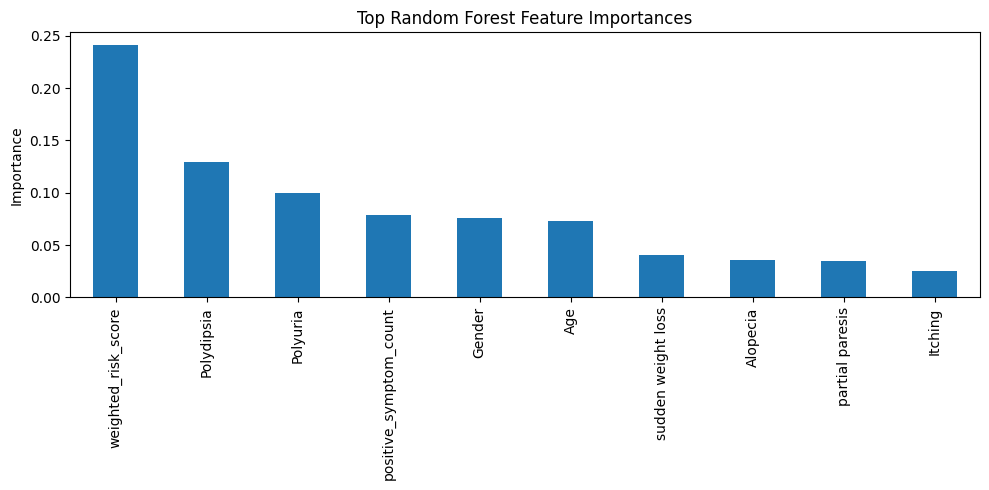

In [90]:

plt.figure(figsize=(10,5))
rf_importance.head(10).plot(kind="bar")
plt.title("Top Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [91]:

# Robustness test
top3_features = rf_importance.head(3).index.tolist()
print("Top 3 features removed:", top3_features)

X_reduced = X.drop(columns=top3_features, errors="ignore")

# Manually define numeric columns for reduced data
base_numeric = ["Age", "positive_symptom_count", "weighted_risk_score"]
num_cols_r = [c for c in base_numeric if c in X_reduced.columns]
cat_cols_r = [c for c in X_reduced.columns if c not in num_cols_r]

print("Reduced numerical columns:", num_cols_r)
print("Reduced categorical columns:", cat_cols_r)

pre_reduced = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols_r),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols_r)
])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

reduced_model = Pipeline([
    ("pre", pre_reduced),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        n_jobs=1
    ))
])

reduced_model.fit(Xr_train, yr_train)
pred_r = reduced_model.predict(Xr_test)
proba_r = reduced_model.predict_proba(Xr_test)[:, 1]

robustness_result = pd.DataFrame([{
    "Accuracy after removal": round(accuracy_score(yr_test, pred_r), 4),
    "F1 after removal": round(f1_score(yr_test, pred_r), 4),
    "ROC AUC after removal": round(roc_auc_score(yr_test, proba_r), 4)
}])

robustness_result 


Top 3 features removed: ['weighted_risk_score', 'Polydipsia', 'Polyuria']
Reduced numerical columns: ['Age', 'positive_symptom_count']
Reduced categorical columns: ['Gender', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'age_group']


,Accuracy after removal,F1 after removal,ROC AUC after removal
0,0.9808,0.9844,0.9984



### Interpretation of Robustness Test

The model maintains very high performance even after removing the top three most important features. This indicates the presence of redundancy among symptom indicators and engineered features.

In this dataset, composite features such as weighted_risk_score and positive_symptom_count help preserve predictive information, even when key raw symptoms are removed. This suggests that while clinically important symptoms remain influential, the model does not rely exclusively on a single predictor or a small subset of features.

Overall, the results demonstrate that the model is robust and capable of generalizing based on multiple overlapping signals.

### Which Features are Indispensable

Based on mutual information and model based importance, the most influential features include:

- Polydipsia  
- Polyuria  
- Weighted risk score  
- Positive symptom count  
- Age  
- Supporting indicators such as partial paresis and sudden weight loss  

Although these features are highly important, the robustness test shows that the model can still perform well without them, indicating that they are influential rather than strictly indispensable.

### Real World Deployment Thinking

A practical deployment design for this model would include:

1. A structured symptom intake interface through a clinic system or patient facing application  
2. Input validation to ensure consistent and standardized Yes or No responses  
3. A lightweight prediction API serving the trained model in real time  
4. A clinician facing explanation module highlighting the most contributing symptoms  
5. Threshold based triage, where high risk patients are flagged for further diagnostic testing  
6. Continuous monitoring for data drift, especially as symptom reporting patterns may vary across populations  

Such a system would function as a decision support tool, improving early screening efficiency while ensuring that final diagnosis remains under clinical supervision.


## Final Conclusion

This study demonstrates that machine learning models can effectively predict the target class using symptom based and demographic features.

Through exploratory data analysis, it was observed that individual symptoms are not independent and often exhibit interaction effects. Feature engineering, particularly the creation of positive symptom count and weighted risk score, significantly improved the representation of the data.

Among the models evaluated, Decision Tree and Random Forest outperformed Logistic Regression, highlighting the importance of capturing non linear relationships in this dataset. While Random Forest provided the highest predictive performance, Decision Tree offered a better balance between interpretability and accuracy.

The robustness test further confirmed that the model does not rely solely on a small set of features, indicating strong generalization capability and redundancy within the dataset.

Overall, the results suggest that the developed model is suitable for use as a clinical screening support tool. However, it should be used to assist healthcare professionals rather than replace clinical judgment, ensuring both reliability and interpretability in real world applications.